### Imports + Seed + Device

In [81]:
import random
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import os
import pandas as pd
import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic=True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch:", torch.__version__)





Device: cpu
Torch: 2.10.0+cu128


### Define dataset paths + verify they exist

I am setting the 4 folder paths (train pos/neg, test pos/neg) and make sure they exist.I have to be 100% sure the notebook is pointing to the right folders. This prevents silent bugs later.

In [82]:
import os
import pandas as pd

train_pos_path = "../aclImdb/train/pos"
train_neg_path = "../aclImdb/train/neg"
test_pos_path  = "../aclImdb/test/pos"
test_neg_path  = "../aclImdb/test/neg"

for p in [ train_pos_path, train_neg_path, test_pos_path, test_neg_path]:
    assert os.path.exists(p), f"Path not found: {p}"
print("Dataset path found")



Dataset path found


### load_dataset(folder)

Here I write the function that reads all .txt files in a folder and returns a list of review strings. This is very important for building train and test df

In [83]:
def load_dataset(folder):
    """
    Reads all text files in the specified folder and returns their content as a list.
    """
    texts = []
    for filename in os.listdir(folder):
        if not filename.endswith(".txt"):
            continue
        filepath = os.path.join(folder, filename)
        with open(filepath, "r", encoding="utf-8") as f:
            texts.append(f.read())
    return texts


### sanity test

In [84]:
sample = load_dataset(train_pos_path)
print("Loaded:", len(sample))
print("First 200 chars:\n", sample[0][:200])


Loaded: 12500
First 200 chars:
 "Hollywood North" is an euphemism from the movie industry as they went to Canada to make movies because of tax breaks and cheaper costs in a civilized city like Toronto, in this case, later in Vancouv


### Load all splits + build DataFrames

Now I will Load train_pos, train_neg, test_pos, test_neg and build train_df and test_df and last but not least I will run Udacity asserts to make sure i get the same results as in the notebook

This is important because i need a structured tabular data before splitting it and tokenizing it



In [85]:
train_pos = load_dataset(train_pos_path)
train_neg = load_dataset(train_neg_path)
test_pos = load_dataset(test_pos_path)
test_neg = load_dataset(test_neg_path)

print("train_pos:", len(train_pos))
print("train_neg:", len(train_neg))
print("test_pos:", len(test_pos))
print("test_neg:", len(test_neg))
      

train_pos: 12500
train_neg: 12500
test_pos: 12500
test_neg: 12500


### Now I will convert the data into pandas dataframes to make handling the datasets easier.

In [86]:
train_df = pd.DataFrame({
    "review": train_pos + train_neg,
    "label": [1] * len(train_pos) + [0] * len(train_neg)
})

test_df = pd.DataFrame({
    "review": test_pos + test_neg,
    "label": [1] * len(test_pos) + [0] * len(test_neg)
})

print(train_df.head())




                                              review  label
0  "Hollywood North" is an euphemism from the mov...      1
1  I found this film the first time when I was se...      1
2  This is one of those movies that I've seen so ...      1
3  Princess Victoria (Emily Blunt) is in line for...      1
4  I have seen the film a few days back on a vide...      1


### Validate Udacity Notebook Assert

In [87]:
assert train_df.shape[0] == 25000, "Training dataset does not have 25000 rows."
assert test_df.shape[0] == 25000, "Testing dataset does not have 25000 rows."
assert train_df.shape[1] == 2, "Training dataset does not have exactly 2 columns."
assert test_df.shape[1] == 2, "Testing dataset does not have exactly 2 columns."

print("Train/Test DataFrames validated")

Train/Test DataFrames validated


### Explore the Dataset

In this section I will check the data frame structure, than i will plot the label distribution. After this I will analyze the review length and last but not least I will print a sample of the postive and negative reviews

The exploration will help me to understand the dataset's structure and distribution.

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 32.0 MB
None
             label
count  25000.00000
mean       0.50000
std        0.50001
min        0.00000
25%        0.00000
50%        0.50000
75%        1.00000
max        1.00000

Label counts:
 label
0    12500
1    12500
Name: count, dtype: int64


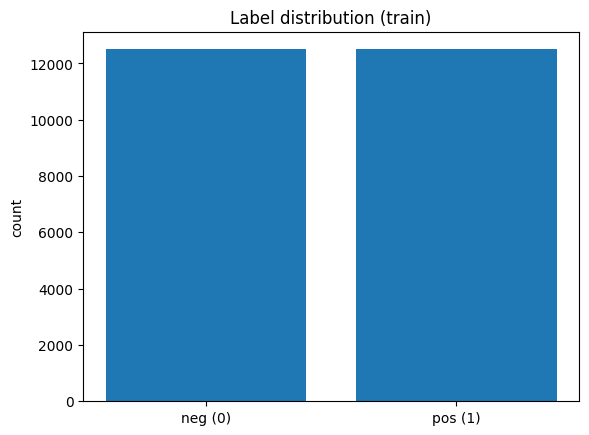

In [88]:
 # Dataset Overview
print(train_df.info())
print(train_df.describe())

# Label Distribution
label_counts=train_df["label"].value_counts().sort_index()
print("\nLabel counts:\n", label_counts)

plt.figure()
plt.bar(["neg (0)", "pos (1)"], [label_counts[0], label_counts[1]])
plt.title("Label distribution (train)")
plt.ylabel("count")
plt.show()